In [60]:
# Importing the dependenciespython -m pip install ipykernel jupyter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

Data Analysis and Preprocessing

In [12]:
df = pd.read_csv('../../datasets/house_price_regression_dataset.csv')

In [13]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [14]:
# house price doesnt need that big of float precision
df["House_Price"] = df["House_Price"].round(0)

In [15]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,262383.0
1,4272,3,3,2016,4.753014,1,6,985261.0
2,3592,1,2,2016,3.634823,0,9,777977.0
3,966,1,2,1977,2.730667,1,8,229699.0
4,4926,2,1,1993,4.699073,0,8,1041741.0


In [16]:
df.shape

(1000, 8)

In [17]:
# checking missing values
df.isna().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

we have 0 null haves in dataset

In [18]:
# checking data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


we have lot size and house price as float and others as integers

In [19]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116270e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016478e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282675e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271410e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


mean and standard deviation are spread far apart; need for standardization

In [20]:
df.nunique()

Square_Footage           894
Num_Bedrooms               5
Num_Bathrooms              3
Year_Built                73
Lot_Size                1000
Garage_Size                3
Neighborhood_Quality      10
House_Price             1000
dtype: int64

one temporal variable, 3 continuous variable (including output) and 4 discrete variables.

In [21]:
df.duplicated().unique()

array([False])

no duplicate values

# Temporal Variable

checking the impact of temporal variable (year built) in price

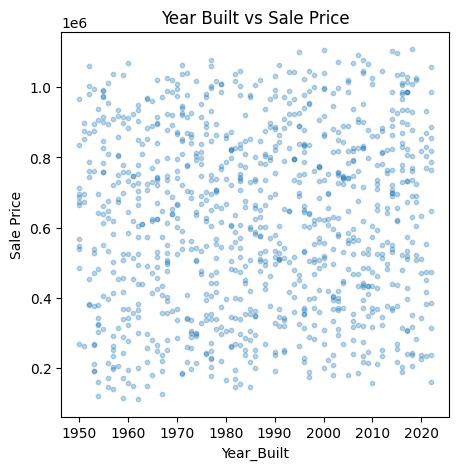

In [ ]:
fig = plt.figure(figsize=(5, 5))
plt.scatter(df['Year_Built'], df['House_Price'], alpha=0.3, s=10)
plt.xlabel('Year_Built')
plt.ylabel('Sale Price')
plt.title('Year Built vs Sale Price')
plt.show()

cant see any meaningful trend

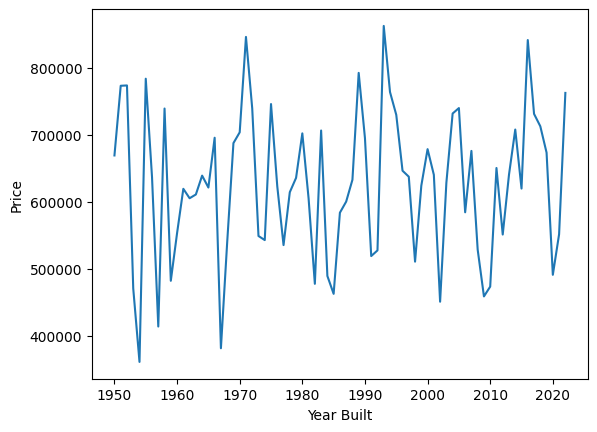

In [34]:
df.groupby('Year_Built')['House_Price'].median().plot()
plt.xlabel('Year Built')
plt.ylabel('Price')
plt.show()

still cant see any meaningful trend; lets try with decades

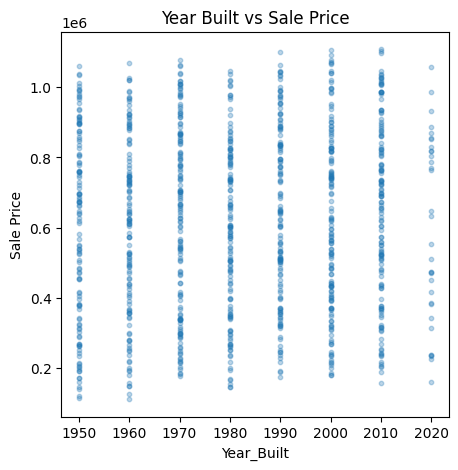

In [ ]:
fig = plt.figure(figsize=(5, 5))
plt.scatter((df['Year_Built']//10)*10, df['House_Price'], alpha=0.3, s=10)
plt.xlabel('Year_Built')
plt.ylabel('Sale Price')
plt.title('Year Built vs Sale Price')
plt.show()

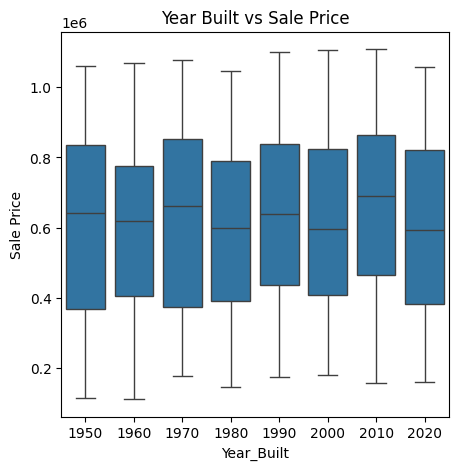

In [32]:
plt.figure(figsize=(5, 5))
sns.boxplot(x = (df['Year_Built']//10)*10, y = df['House_Price'])
plt.xlabel('Year_Built')
plt.ylabel('Sale Price')
plt.title('Year Built vs Sale Price')
plt.show()

Year built is not a super impactful factor in sale price

# Discrete Variable

In [36]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,262383.0
1,4272,3,3,2016,4.753014,1,6,985261.0
2,3592,1,2,2016,3.634823,0,9,777977.0
3,966,1,2,1977,2.730667,1,8,229699.0
4,4926,2,1,1993,4.699073,0,8,1041741.0


In [40]:
discrete_features = [feature for feature in df.columns if df[feature].nunique() <=10]
print('Number of discrete variables: ', len(discrete_features))
df[discrete_features].head()

Number of discrete variables:  4


,Num_Bedrooms,Num_Bathrooms,Garage_Size,Neighborhood_Quality
0,2,1,0,5
1,3,3,1,6
2,1,2,0,9
3,1,2,1,8
4,2,1,0,8


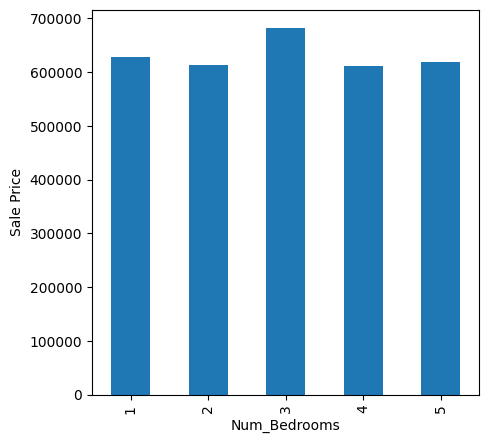

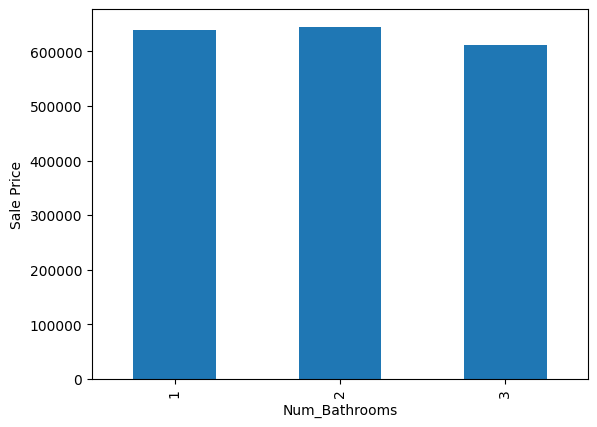

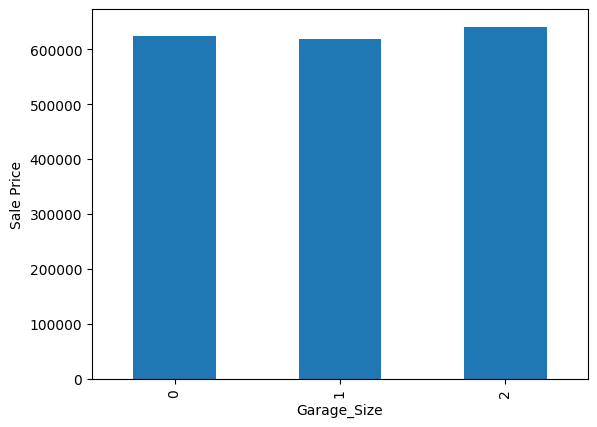

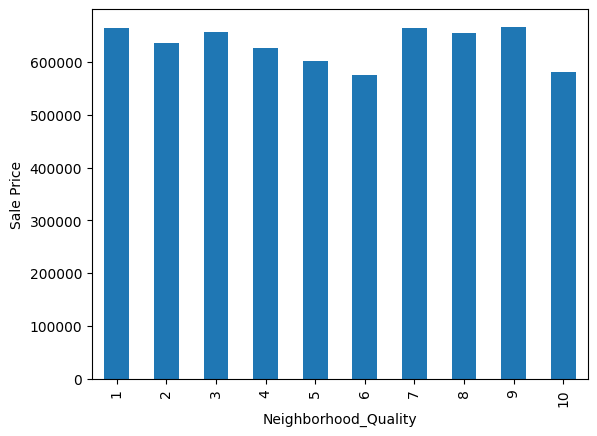

In [46]:
fig = plt.figure(figsize=(5,5))
for feature in discrete_features:
    df.groupby(feature)['House_Price'].median().plot.bar()
    plt.xlabel(feature)
    plt.ylabel('Sale Price')
    plt.show()

discrete variables does not have that big of impact and prices tend to be around 60k

# Continuous variable

In [49]:
continuous_features = [feature for feature in df.columns if feature not in discrete_features+['Year_Built']+['House_Price']]
print("Continuous Variables Count: {}".format(len(continuous_features)))
df[continuous_features].head()

Continuous Variables Count: 2


,Square_Footage,Lot_Size
0,1360,0.599637
1,4272,4.753014
2,3592,3.634823
3,966,2.730667
4,4926,4.699073


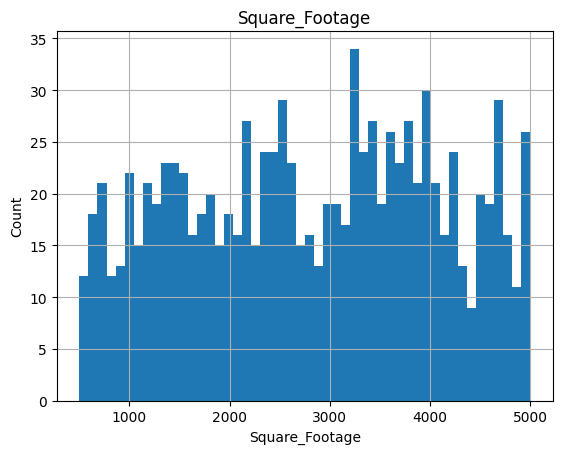

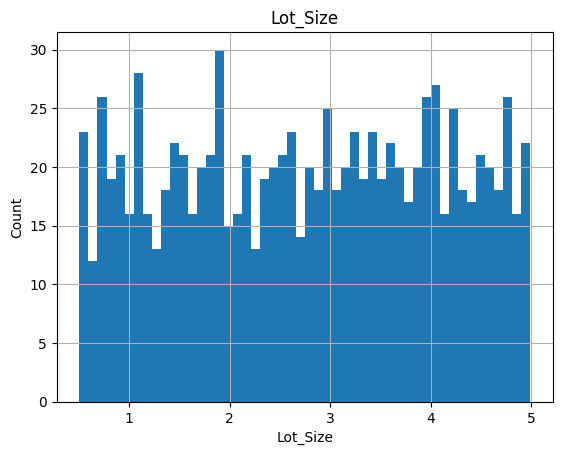

In [54]:
for feature in continuous_features:
    df[feature].hist(bins=50)
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(feature)
    plt.show()

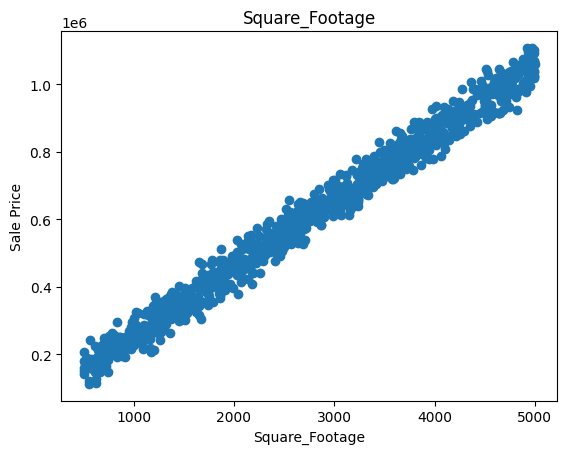

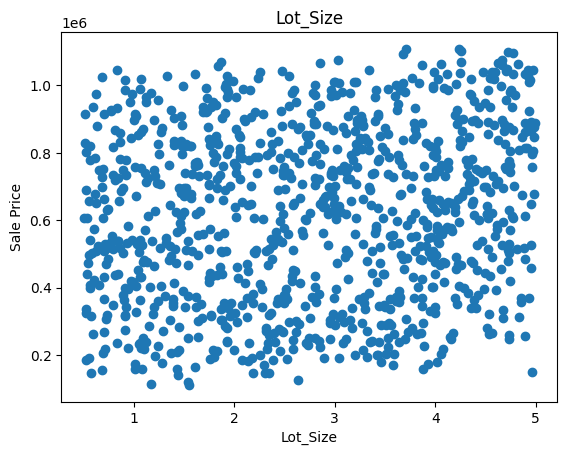

In [58]:
for feature in continuous_features:
    plt.scatter(df[feature], df['House_Price'])
    plt.xlabel(feature)
    plt.ylabel('Sale Price')
    plt.title(feature)
    plt.show()

square foot has the most significant and positive correlation with house price

# Preprocessing

In [62]:
X = df.drop(columns=['House_Price'])
print(X)
Y = df['House_Price']
print(Y)

     Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0              1360             2              1        1981  0.599637   
1              4272             3              3        2016  4.753014   
2              3592             1              2        2016  3.634823   
3               966             1              2        1977  2.730667   
4              4926             2              1        1993  4.699073   
..              ...           ...            ...         ...       ...   
995            3261             4              1        1978  2.165110   
996            3179             1              2        1999  2.977123   
997            2606             4              2        1962  4.055067   
998            4723             5              2        1950  1.930921   
999            3268             4              2        1983  3.108790   

     Garage_Size  Neighborhood_Quality  
0              0                     5  
1              1             

In [64]:
# train test split
X_train, Y_train, X_test, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

In [66]:
X.shape, X_train.shape, Y_train.shape

((1000, 7), (800, 7), (200, 7))

In [69]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,262383.0
1,4272,3,3,2016,4.753014,1,6,985261.0
2,3592,1,2,2016,3.634823,0,9,777977.0
3,966,1,2,1977,2.730667,1,8,229699.0
4,4926,2,1,1993,4.699073,0,8,1041741.0


In [72]:
numerical_columns = ['Square_Footage', 'Lot_Size']
categorical_columns = [
    'Num_Bedrooms',
    'Num_Bathrooms	',
    'Year_Built',
    'Garage_Size',
    'Neighborhood_Quality'
]
preprocessor = ColumnTransformer(
    [
        ('num_scaler', StandardScaler(), continuous_features),
        ('cat_scaler', StandardScaler(with_mean=False), discrete_features+['Year_Built'])
    ]
)

In [73]:
scaled_X_train = preprocessor.fit_transform(X_train)